In [ ]:
import os, sys

# Make sure this notebook works regardless of Jupyter's starting directory:
# CSV paths and the `data_loaders`/`config`/`model` imports below all assume
# the current working directory is the project root (one level up from
# notebooks/).
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
os.chdir(PROJECT_ROOT)
sys.path.append(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

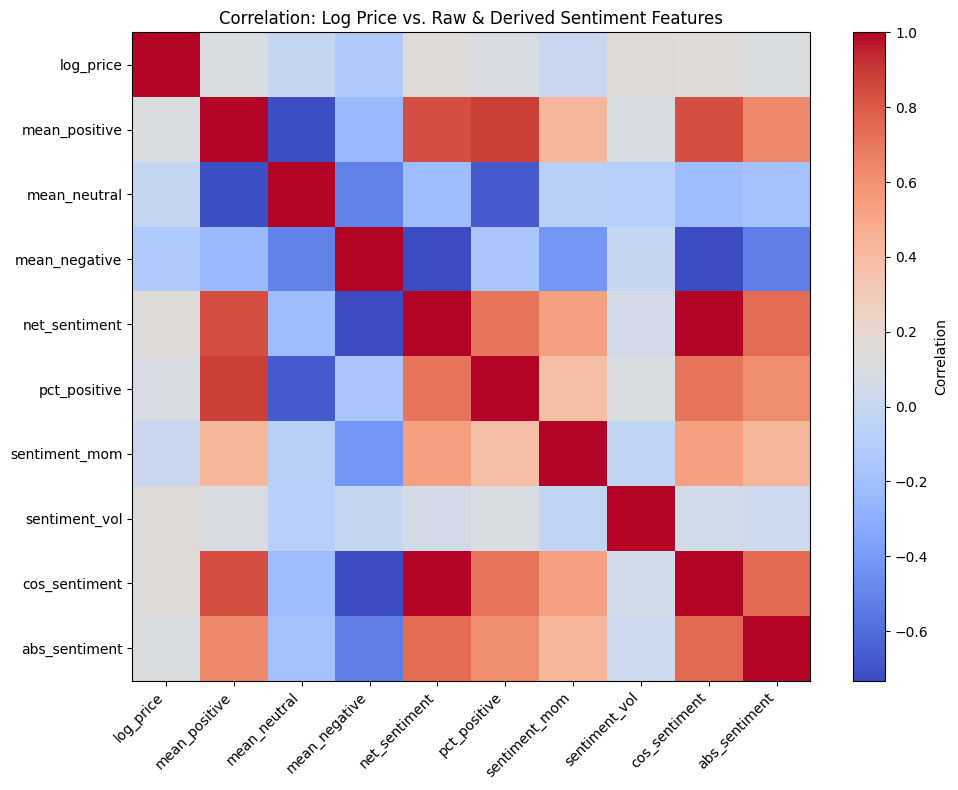

In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# Paths to your data files
# ─────────────────────────────────────────────────────────────────────────────
spy_path  = "data/spy_2012_2025.csv"
sent_path = "data/3D_articles_new_version_hm.csv"

# ─────────────────────────────────────────────────────────────────────────────
# 1) Load & prep SPY prices
# ─────────────────────────────────────────────────────────────────────────────
spy = (
    pd.read_csv(
        spy_path,
        skiprows=[1,2],
        parse_dates=["Price"],
        index_col="Price",
        usecols=["Price","price"]
    )
    .asfreq("B")
    .ffill()
)
spy.index.name = "date"
spy["log_price"] = np.log(spy["price"])

# ─────────────────────────────────────────────────────────────────────────────
# 2) Load raw sentiment data
# ─────────────────────────────────────────────────────────────────────────────
raw = pd.read_csv(sent_path, parse_dates=["date"])
raw["date"]     = raw["date"].dt.normalize()
raw["polarity"] = raw["mean_positive"] - raw["mean_negative"]

# derive simple label for ratios
def maj_lab(r):
    m = max(r.mean_positive, r.mean_neutral, r.mean_negative)
    if   m == r.mean_positive: return "positive"
    elif m == r.mean_negative: return "negative"
    else:                      return "neutral"

raw["label"] = raw.apply(maj_lab, axis=1)

# ─────────────────────────────────────────────────────────────────────────────
# 3) Build continuous business-day index for sentiment
# ─────────────────────────────────────────────────────────────────────────────
grp = raw.groupby("date")
daily = pd.DataFrame(index=grp.size().index)
daily = (
    daily
      .asfreq("B")
      .ffill()
      .fillna(0.0)
)

# 4) Compute all sentiment features
daily["mean_positive"] = grp["mean_positive"].mean()
daily["mean_neutral"]  = grp["mean_neutral"].mean()
daily["mean_negative"] = grp["mean_negative"].mean()
daily["net_sentiment"] = grp["polarity"].mean()

# get raw counts per day
counts = grp["label"].value_counts().unstack(fill_value=0)

# make sure counts is indexed the same as daily (fills missing business days with zeros)
counts = counts.reindex(daily.index, fill_value=0)

# compute total articles per day
totals = counts.sum(axis=1)              # Series of shape (dates,)

# vectorized percentage positive, safely handling zero‐total days
daily["pct_positive"] = (
    counts["positive"]
    .div(totals)       # elementwise division
    .fillna(0.0)       # days with total==0 become NaN → 0
)

# if you want it as a percent rather than 0–1, do:
# daily["pct_positive"] *= 100

daily["sentiment_mom"] = daily["net_sentiment"].diff().fillna(0)
daily["sentiment_vol"] = daily["net_sentiment"].rolling(7, min_periods=1).std()

# 5) Cosine-based sentiment (unchanged)
P, Neu, N = daily["mean_positive"], daily["mean_neutral"], daily["mean_negative"]
vec_norm  = np.sqrt(P**2 + Neu**2 + N**2)
daily["cos_sentiment"] = ((P - N) / (vec_norm * np.sqrt(2))).fillna(0.0)

# ─────────────────────────────────────────────────────────────────────────────
# 6) Absolute-dominance sentiment
# ─────────────────────────────────────────────────────────────────────────────
pos_dom = (P >= Neu) & (P >= N)
neg_dom = (N >  Neu) & (N >  P)

daily["abs_sentiment"] = 0.0
daily.loc[pos_dom, "abs_sentiment"] =  P[pos_dom]
daily.loc[neg_dom, "abs_sentiment"] = -N[neg_dom]

# ─────────────────────────────────────────────────────────────────────────────
# 7) Align with log_price and compute correlation matrix
# ─────────────────────────────────────────────────────────────────────────────
df = daily.join(spy[["log_price"]], how="inner").dropna()

features = [
    "log_price",
    "mean_positive", "mean_neutral", "mean_negative",
    "net_sentiment", "pct_positive",
    "sentiment_mom", "sentiment_vol",
    "cos_sentiment", "abs_sentiment"
]

corr = df[features].corr()

# ─────────────────────────────────────────────────────────────────────────────
# 8) Plot heatmap
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(features)), features, rotation=45, ha="right")
plt.yticks(range(len(features)), features)
plt.title("Correlation: Log Price vs. Raw & Derived Sentiment Features")
plt.tight_layout()
plt.show()


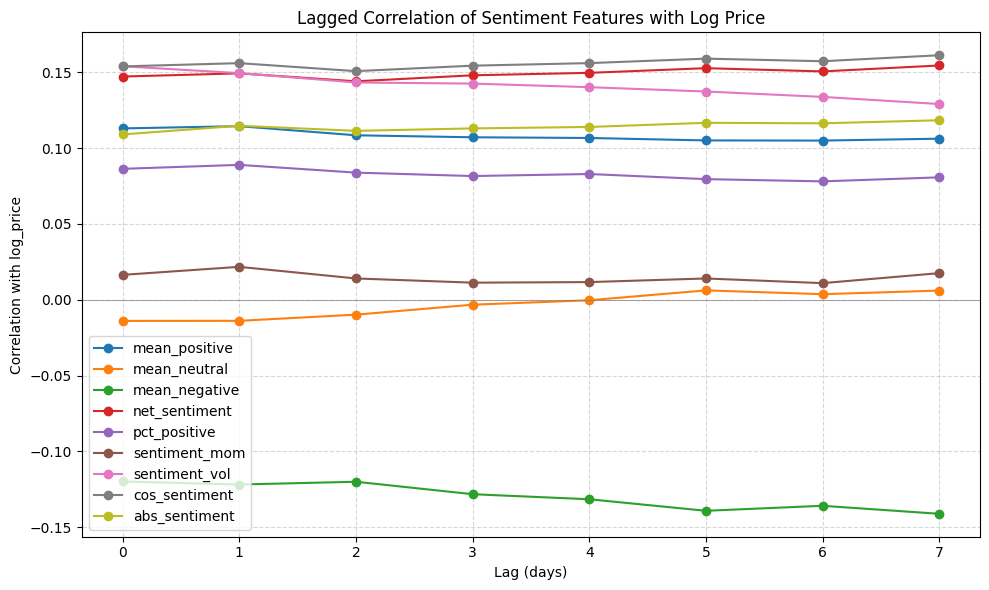

Lagged correlations (rows=lag 0…7):
    mean_positive  mean_neutral  mean_negative  net_sentiment  pct_positive  \
0       0.113045     -0.013969      -0.119920       0.147264      0.086372   
1       0.114513     -0.013914      -0.121918       0.149369      0.088990   
2       0.108503     -0.009846      -0.120091       0.144116      0.083874   
3       0.107193     -0.003270      -0.128305       0.148083      0.081611   
4       0.106735     -0.000350      -0.131640       0.149702      0.082953   
5       0.105115      0.006171      -0.139258       0.152788      0.079569   
6       0.105012      0.003663      -0.135953       0.150649      0.078101   
7       0.106259      0.006040      -0.141236       0.154559      0.080751   

   sentiment_mom  sentiment_vol  cos_sentiment  abs_sentiment  
0       0.016410       0.154041       0.153945       0.109065  
1       0.021708       0.149504       0.156106       0.114785  
2       0.014041       0.143339       0.150832       0.111442  
3   

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5) Compute lagged correlations
# ─────────────────────────────────────────────────────────────────────────────
max_lag  = 7
# Remove log_price from the list
features = [col for col in features if col != "log_price"]

corrs = pd.DataFrame(
    {feat: [df[feat].shift(lag).corr(df["log_price"]) for lag in range(max_lag+1)]
     for feat in features},
    index=range(max_lag+1)
)


# ─────────────────────────────────────────────────────────────────────────────
# 6) Plot the lag curves
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10,6))
for feat in features:
    plt.plot(corrs.index, corrs[feat], marker='o', label=feat)
plt.axhline(0, color='gray', linewidth=0.5)
plt.xticks(corrs.index)
plt.xlabel("Lag (days)")
plt.ylabel("Correlation with log_price")
plt.title("Lagged Correlation of Sentiment Features with Log Price")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 7) (Optional) print or display the table
# ─────────────────────────────────────────────────────────────────────────────
print("Lagged correlations (rows=lag 0…7):\n", corrs)


To handle missing data we ffill the price and sentiment data

## Distance correlation

Mag 7 and Tariff Features

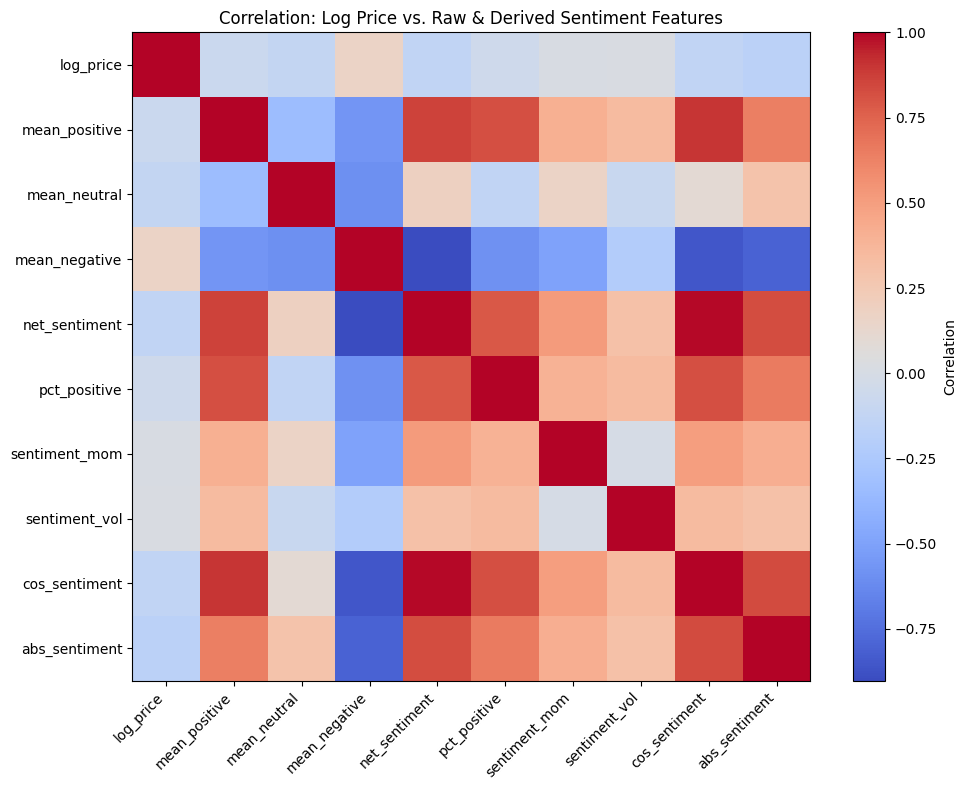

In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# Paths to your data files
# ─────────────────────────────────────────────────────────────────────────────
spy_path  = "data/spy_2012_2025.csv"
sent_path = "data/3D_articles_Mag_7_hm.csv"

# ─────────────────────────────────────────────────────────────────────────────
# 1) Load & prep SPY prices
# ─────────────────────────────────────────────────────────────────────────────
spy = (
    pd.read_csv(
        spy_path,
        skiprows=[1,2],
        parse_dates=["Price"],
        index_col="Price",
        usecols=["Price","price"]
    )
    .asfreq("B")
    .ffill()
)
spy.index.name = "date"
spy["log_price"] = np.log(spy["price"])

# ─────────────────────────────────────────────────────────────────────────────
# 2) Load raw sentiment data
# ─────────────────────────────────────────────────────────────────────────────
raw = pd.read_csv(sent_path, parse_dates=["date"])
raw["date"]     = raw["date"].dt.normalize()
raw["polarity"] = raw["mean_positive"] - raw["mean_negative"]

# derive simple label for ratios
def maj_lab(r):
    m = max(r.mean_positive, r.mean_neutral, r.mean_negative)
    if   m == r.mean_positive: return "positive"
    elif m == r.mean_negative: return "negative"
    else:                      return "neutral"

raw["label"] = raw.apply(maj_lab, axis=1)

# ─────────────────────────────────────────────────────────────────────────────
# 3) Build continuous business-day index for sentiment
# ─────────────────────────────────────────────────────────────────────────────
grp = raw.groupby("date")
daily = pd.DataFrame(index=grp.size().index)
daily = (
    daily
      .asfreq("B")
      .ffill()
      .fillna(0.0)
)

# 4) Compute all sentiment features
daily["mean_positive"] = grp["mean_positive"].mean()
daily["mean_neutral"]  = grp["mean_neutral"].mean()
daily["mean_negative"] = grp["mean_negative"].mean()
daily["net_sentiment"] = grp["polarity"].mean()

# get raw counts per day
counts = grp["label"].value_counts().unstack(fill_value=0)

# make sure counts is indexed the same as daily (fills missing business days with zeros)
counts = counts.reindex(daily.index, fill_value=0)

# compute total articles per day
totals = counts.sum(axis=1)              # Series of shape (dates,)

# vectorized percentage positive, safely handling zero‐total days
daily["pct_positive"] = (
    counts["positive"]
    .div(totals)       # elementwise division
    .fillna(0.0)       # days with total==0 become NaN → 0
)

# if you want it as a percent rather than 0–1, do:
# daily["pct_positive"] *= 100

daily["sentiment_mom"] = daily["net_sentiment"].diff().fillna(0)
daily["sentiment_vol"] = daily["net_sentiment"].rolling(7, min_periods=1).std()

# 5) Cosine-based sentiment (unchanged)
P, Neu, N = daily["mean_positive"], daily["mean_neutral"], daily["mean_negative"]
vec_norm  = np.sqrt(P**2 + Neu**2 + N**2)
daily["cos_sentiment"] = ((P - N) / (vec_norm * np.sqrt(2))).fillna(0.0)

# ─────────────────────────────────────────────────────────────────────────────
# 6) Absolute-dominance sentiment
# ─────────────────────────────────────────────────────────────────────────────
pos_dom = (P >= Neu) & (P >= N)
neg_dom = (N >  Neu) & (N >  P)

daily["abs_sentiment"] = 0.0
daily.loc[pos_dom, "abs_sentiment"] =  P[pos_dom]
daily.loc[neg_dom, "abs_sentiment"] = -N[neg_dom]

# ─────────────────────────────────────────────────────────────────────────────
# 7) Align with log_price and compute correlation matrix
# ─────────────────────────────────────────────────────────────────────────────
df = daily.join(spy[["log_price"]], how="inner").dropna()

features = [
    "log_price",
    "mean_positive", "mean_neutral", "mean_negative",
    "net_sentiment", "pct_positive",
    "sentiment_mom", "sentiment_vol",
    "cos_sentiment", "abs_sentiment"
]

corr = df[features].corr()

# ─────────────────────────────────────────────────────────────────────────────
# 8) Plot heatmap
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(features)), features, rotation=45, ha="right")
plt.yticks(range(len(features)), features)
plt.title("Correlation: Log Price vs. Raw & Derived Sentiment Features")
plt.tight_layout()
plt.show()


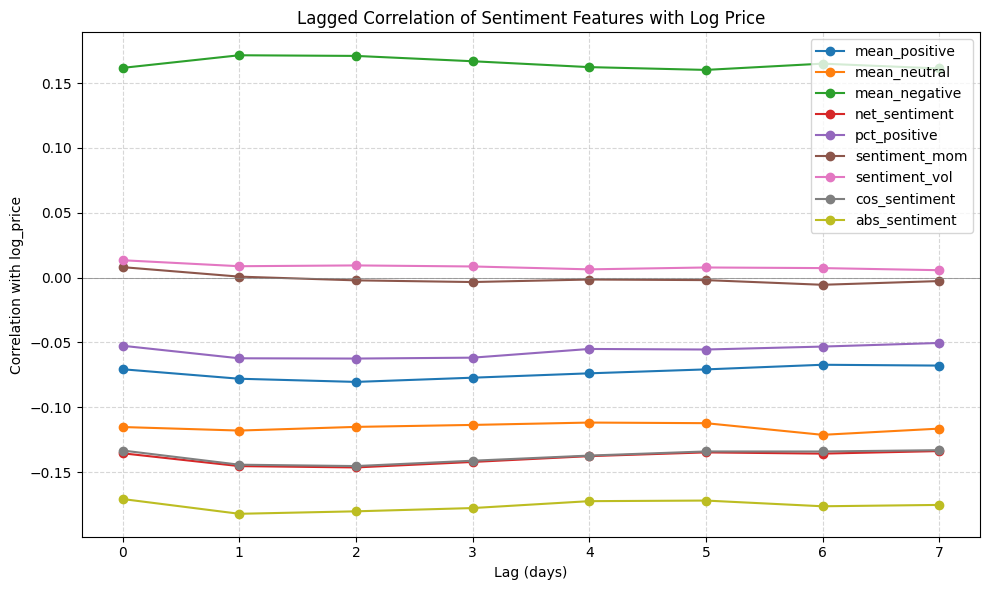

Lagged correlations (rows=lag 0…7):
    mean_positive  mean_neutral  mean_negative  net_sentiment  pct_positive  \
0      -0.070681     -0.115234       0.161779      -0.135485     -0.052560   
1      -0.077988     -0.117954       0.171510      -0.145383     -0.062215   
2      -0.080433     -0.115133       0.171005      -0.146400     -0.062422   
3      -0.077185     -0.113610       0.166898      -0.142171     -0.061737   
4      -0.073817     -0.111794       0.162365      -0.137689     -0.055024   
5      -0.070783     -0.112260       0.160211      -0.134801     -0.055452   
6      -0.067206     -0.121254       0.165044      -0.135747     -0.053184   
7      -0.067848     -0.116461       0.161304      -0.133785     -0.050397   

   sentiment_mom  sentiment_vol  cos_sentiment  abs_sentiment  
0       0.008076       0.013407      -0.133346      -0.170771  
1       0.000768       0.008798      -0.144289      -0.182159  
2      -0.002108       0.009410      -0.145345      -0.180249  
3   

In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# 5) Compute lagged correlations
# ─────────────────────────────────────────────────────────────────────────────
max_lag  = 7
# Remove log_price from the list
features = [col for col in features if col != "log_price"]

corrs = pd.DataFrame(
    {feat: [df[feat].shift(lag).corr(df["log_price"]) for lag in range(max_lag+1)]
     for feat in features},
    index=range(max_lag+1)
)


# ─────────────────────────────────────────────────────────────────────────────
# 6) Plot the lag curves
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10,6))
for feat in features:
    plt.plot(corrs.index, corrs[feat], marker='o', label=feat)
plt.axhline(0, color='gray', linewidth=0.5)
plt.xticks(corrs.index)
plt.xlabel("Lag (days)")
plt.ylabel("Correlation with log_price")
plt.title("Lagged Correlation of Sentiment Features with Log Price")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 7) (Optional) print or display the table
# ─────────────────────────────────────────────────────────────────────────────
print("Lagged correlations (rows=lag 0…7):\n", corrs)


Tariffs

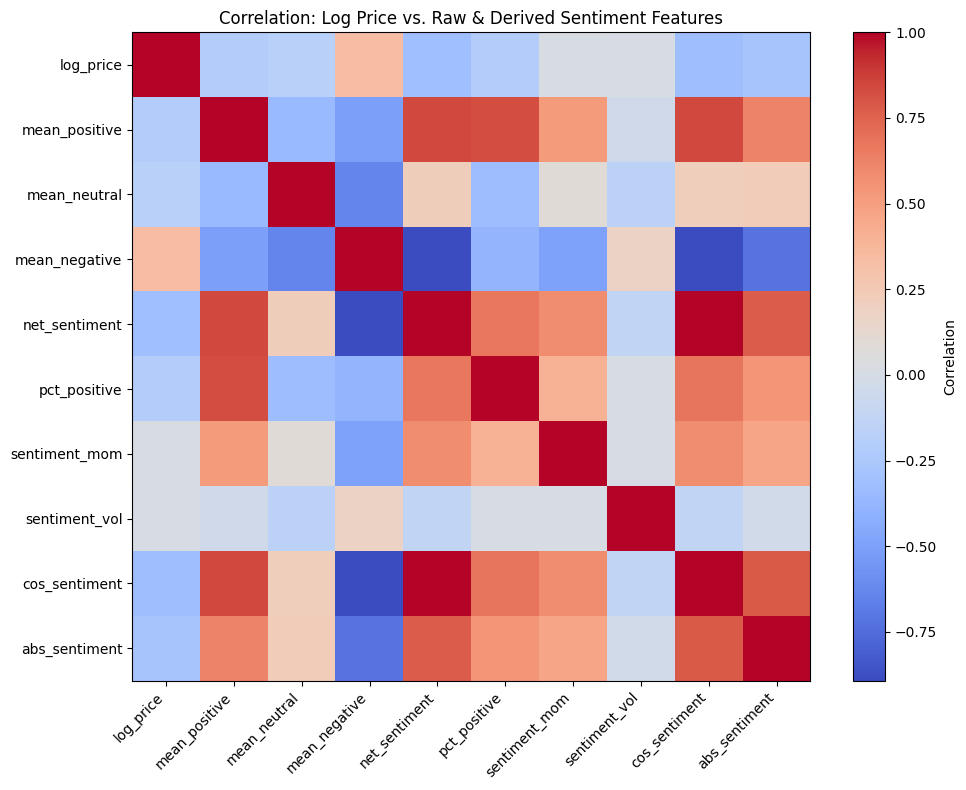

In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# Paths to your data files
# ─────────────────────────────────────────────────────────────────────────────
spy_path  = "data/spy_2012_2025.csv"
sent_path = "data/3D_articles_Tariff_hm.csv"

# ─────────────────────────────────────────────────────────────────────────────
# 1) Load & prep SPY prices
# ─────────────────────────────────────────────────────────────────────────────
spy = (
    pd.read_csv(
        spy_path,
        skiprows=[1,2],
        parse_dates=["Price"],
        index_col="Price",
        usecols=["Price","price"]
    )
    .asfreq("B")
    .ffill()
)
spy.index.name = "date"
spy["log_price"] = np.log(spy["price"])

# ─────────────────────────────────────────────────────────────────────────────
# 2) Load raw sentiment data
# ─────────────────────────────────────────────────────────────────────────────
raw = pd.read_csv(sent_path, parse_dates=["date"])
raw["date"]     = raw["date"].dt.normalize()
raw["polarity"] = raw["mean_positive"] - raw["mean_negative"]

# derive simple label for ratios
def maj_lab(r):
    m = max(r.mean_positive, r.mean_neutral, r.mean_negative)
    if   m == r.mean_positive: return "positive"
    elif m == r.mean_negative: return "negative"
    else:                      return "neutral"

raw["label"] = raw.apply(maj_lab, axis=1)

# ─────────────────────────────────────────────────────────────────────────────
# 3) Build continuous business-day index for sentiment
# ─────────────────────────────────────────────────────────────────────────────
grp = raw.groupby("date")
daily = pd.DataFrame(index=grp.size().index)
daily = (
    daily
      .asfreq("B")
      .ffill()
      .fillna(0.0)
)

# 4) Compute all sentiment features
daily["mean_positive"] = grp["mean_positive"].mean()
daily["mean_neutral"]  = grp["mean_neutral"].mean()
daily["mean_negative"] = grp["mean_negative"].mean()
daily["net_sentiment"] = grp["polarity"].mean()

# get raw counts per day
counts = grp["label"].value_counts().unstack(fill_value=0)

# make sure counts is indexed the same as daily (fills missing business days with zeros)
counts = counts.reindex(daily.index, fill_value=0)

# compute total articles per day
totals = counts.sum(axis=1)              # Series of shape (dates,)

# vectorized percentage positive, safely handling zero‐total days
daily["pct_positive"] = (
    counts["positive"]
    .div(totals)       # elementwise division
    .fillna(0.0)       # days with total==0 become NaN → 0
)

# if you want it as a percent rather than 0–1, do:
# daily["pct_positive"] *= 100

daily["sentiment_mom"] = daily["net_sentiment"].diff().fillna(0)
daily["sentiment_vol"] = daily["net_sentiment"].rolling(7, min_periods=1).std()

# 5) Cosine-based sentiment (unchanged)
P, Neu, N = daily["mean_positive"], daily["mean_neutral"], daily["mean_negative"]
vec_norm  = np.sqrt(P**2 + Neu**2 + N**2)
daily["cos_sentiment"] = ((P - N) / (vec_norm * np.sqrt(2))).fillna(0.0)

# ─────────────────────────────────────────────────────────────────────────────
# 6) Absolute-dominance sentiment
# ─────────────────────────────────────────────────────────────────────────────
pos_dom = (P >= Neu) & (P >= N)
neg_dom = (N >  Neu) & (N >  P)

daily["abs_sentiment"] = 0.0
daily.loc[pos_dom, "abs_sentiment"] =  P[pos_dom]
daily.loc[neg_dom, "abs_sentiment"] = -N[neg_dom]

# ─────────────────────────────────────────────────────────────────────────────
# 7) Align with log_price and compute correlation matrix
# ─────────────────────────────────────────────────────────────────────────────
df = daily.join(spy[["log_price"]], how="inner").dropna()

features = [
    "log_price",
    "mean_positive", "mean_neutral", "mean_negative",
    "net_sentiment", "pct_positive",
    "sentiment_mom", "sentiment_vol",
    "cos_sentiment", "abs_sentiment"
]

corr = df[features].corr()

# ─────────────────────────────────────────────────────────────────────────────
# 8) Plot heatmap
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(features)), features, rotation=45, ha="right")
plt.yticks(range(len(features)), features)
plt.title("Correlation: Log Price vs. Raw & Derived Sentiment Features")
plt.tight_layout()
plt.show()


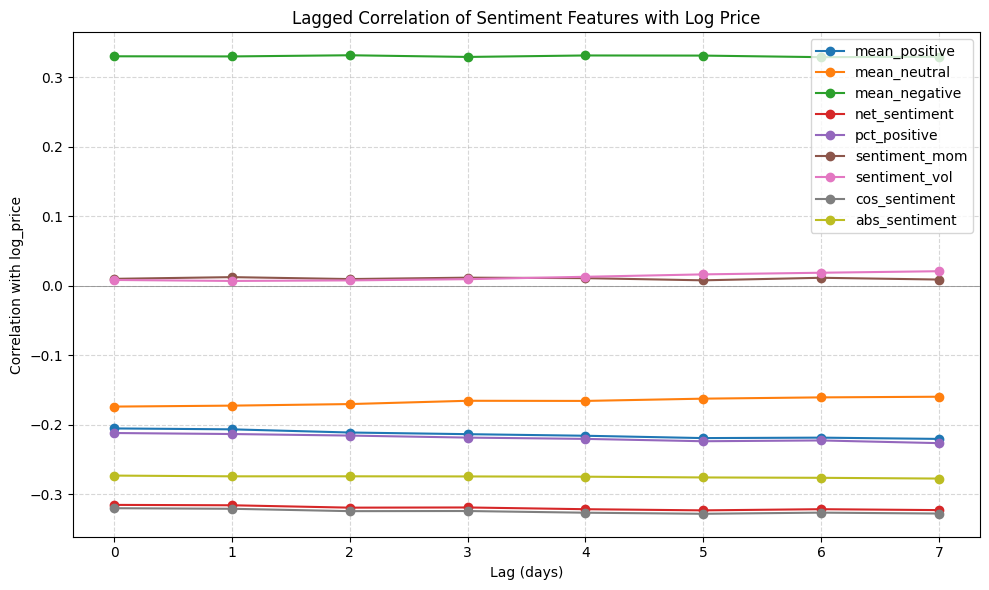

Lagged correlations (rows=lag 0…7):
    mean_positive  mean_neutral  mean_negative  net_sentiment  pct_positive  \
0      -0.205351     -0.173924       0.330010      -0.315342     -0.211941   
1      -0.206651     -0.172546       0.329813      -0.315889     -0.213406   
2      -0.211220     -0.170301       0.331494      -0.319317     -0.215613   
3      -0.213598     -0.165564       0.329077      -0.319045     -0.218530   
4      -0.215881     -0.165774       0.331202      -0.321550     -0.220401   
5      -0.219243     -0.162517       0.331016      -0.323212     -0.223766   
6      -0.218597     -0.160671       0.328761      -0.321536     -0.222633   
7      -0.220423     -0.159750       0.329346      -0.322835     -0.226497   

   sentiment_mom  sentiment_vol  cos_sentiment  abs_sentiment  
0       0.009863       0.008229      -0.320112      -0.273188  
1       0.012312       0.006830      -0.320942      -0.274259  
2       0.009543       0.007613      -0.324351      -0.274227  
3   

In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# 5) Compute lagged correlations
# ─────────────────────────────────────────────────────────────────────────────
max_lag  = 7
# Remove log_price from the list
features = [col for col in features if col != "log_price"]

corrs = pd.DataFrame(
    {feat: [df[feat].shift(lag).corr(df["log_price"]) for lag in range(max_lag+1)]
     for feat in features},
    index=range(max_lag+1)
)


# ─────────────────────────────────────────────────────────────────────────────
# 6) Plot the lag curves
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10,6))
for feat in features:
    plt.plot(corrs.index, corrs[feat], marker='o', label=feat)
plt.axhline(0, color='gray', linewidth=0.5)
plt.xticks(corrs.index)
plt.xlabel("Lag (days)")
plt.ylabel("Correlation with log_price")
plt.title("Lagged Correlation of Sentiment Features with Log Price")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 7) (Optional) print or display the table
# ─────────────────────────────────────────────────────────────────────────────
print("Lagged correlations (rows=lag 0…7):\n", corrs)


C:\Users\hardm\AppData\Local\Temp\ipykernel_31564\3656328959.py:74: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best = kalshi.groupby("trade_date", group_keys=False).apply(pick_best)




===== NET_SENTIMENT =====
Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3732 - val_loss: 0.0808
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0104 - val_loss: 0.0432
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0092 - val_loss: 0.0365
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0075 - val_loss: 0.0355
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0077 - val_loss: 0.0352
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0076 - val_loss: 0.0357
Epoch 7/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0069 - val_loss: 0.0273
Epoch 8/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0067 - val_loss: 0.0291
Epoch 9/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0074 - val_loss: 0.0255
Epoch 10/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0069 - val_loss: 0.0252
Epoch 11/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0065 - val_loss: 0.0236
Epoch 12/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms

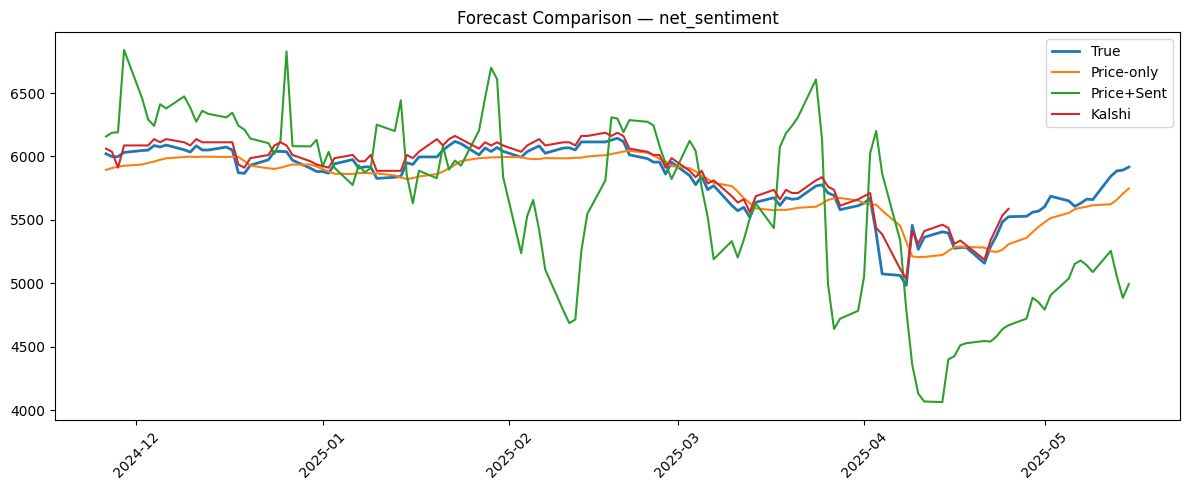



===== POS_NEG_RATIO =====
Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.4213 - val_loss: 0.1101
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0120 - val_loss: 0.0444
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0095 - val_loss: 0.0363
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0087 - val_loss: 0.0293
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0079 - val_loss: 0.0284
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0078 - val_loss: 0.0263
Epoch 7/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0067 - val_loss: 0.0255
Epoch 8/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0065 - val_loss: 0.0248
Epoch 9/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0068 - val_loss: 0.0242
Epoch 10/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0066 - val_loss: 0.0230
Epoch 11/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0074 - val_loss: 0.0208
Epoch 12/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 

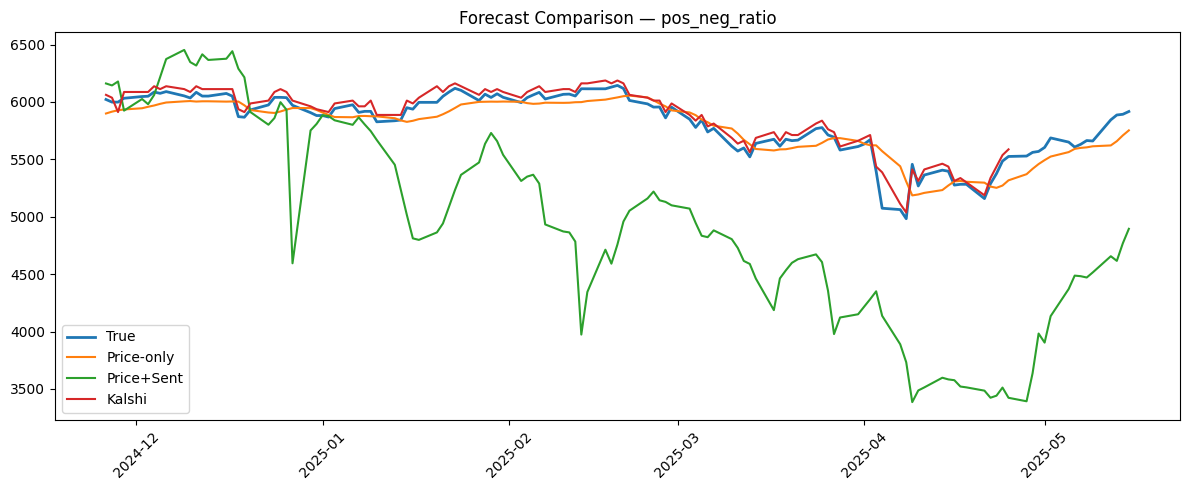



===== SENTIMENT_MOM =====
Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2454 - val_loss: 0.0616
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0094 - val_loss: 0.0420
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0079 - val_loss: 0.0329
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0076 - val_loss: 0.0263
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0071 - val_loss: 0.0207
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0062 - val_loss: 0.0222
Epoch 7/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0055 - val_loss: 0.0191
Epoch 8/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0059 - val_loss: 0.0209
Epoch 9/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0051 - val_loss: 0.0176
Epoch 10/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0056 - val_loss: 0.0192
Epoch 11/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0052 - val_loss: 0.0158
Epoch 12/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms

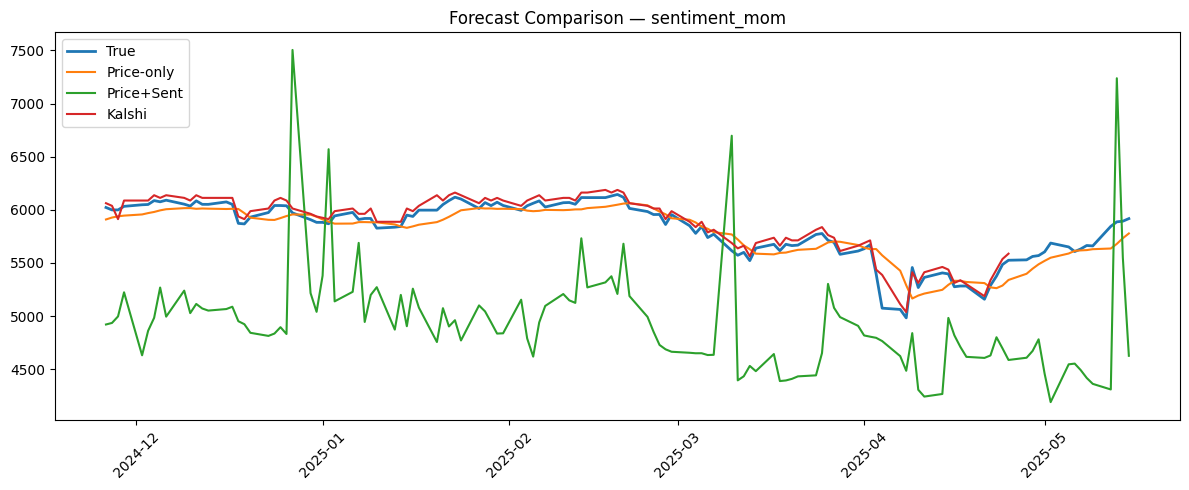



===== SENTIMENT_VOL =====
Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.4938 - val_loss: 0.1256
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0132 - val_loss: 0.0541
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0086 - val_loss: 0.0406
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0079 - val_loss: 0.0388
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0070 - val_loss: 0.0363
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0074 - val_loss: 0.0322
Epoch 7/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0079 - val_loss: 0.0287
Epoch 8/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0069 - val_loss: 0.0259
Epoch 9/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0064 - val_loss: 0.0251
Epoch 10/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0065 - val_loss: 0.0263
Epoch 11/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0066 - val_loss: 0.0284
Epoch 12/40
62/62 ━━━━━━━━━━━━━━━━━━

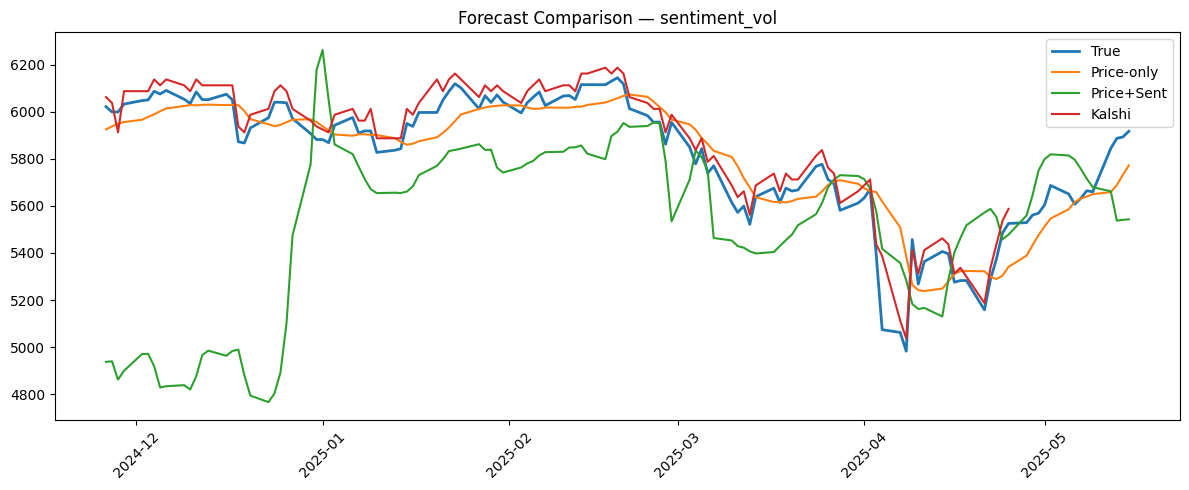

In [ ]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.layers import (
    Input, LSTM, Dropout, Dense,
    Concatenate, BatchNormalization
)
from tensorflow.keras import Model, regularizers
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# ─────────────────────────────────────────────────────────────────────────────
# 0) CONFIG & REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────────────────────
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
for g in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(g, True)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

cfg = {
    "lookback":     30,
    "batch_size":   32,
    "pre_epochs":   40,
    "ft_epochs":    40,
    "lr_pre":       1e-3,
    "lr_ft":        1e-4,
    "train_frac":   0.9,
    "pre_val_frac": 0.1,
    "dropout_rate": 0.1,
    "l2_reg":       1e-5,
}

# ─────────────────────────────────────────────────────────────────────────────
# 1) LOAD & PREP SPX PRICE
# ─────────────────────────────────────────────────────────────────────────────
spy_all = (
    pd.read_csv(
        "data/spy_2012_2025.csv",
        skiprows=[1, 2],
        parse_dates=["Price"],
        index_col="Price",
        usecols=["Price", "price"],
    )
    .asfreq("B")
    .ffill()
)
spy_all.index.name = "date"
spy_all.columns = ["price"]

spy_only_df = spy_all.loc[:"2020-07-29"]
spy_sent_df = spy_all.loc["2020-07-30":]

# ─────────────────────────────────────────────────────────────────────────────
# 2) LOAD & PREP KALSHI
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: kalshi_spy.csv was not present in the original project folder;
# point this at your own Kalshi export (see KXINX_trades_range_vs_sp.csv
# in data/ for the equivalent series used elsewhere in this repo).
kalshi = pd.read_csv("kalshi_spy.csv", parse_dates=["trade_date"])

def pick_best(gr):
    v = gr.dropna(subset=["bucket_start", "bucket_end"])
    if not v.empty:
        return v.loc[v["yes_price"].idxmax()]
    return gr.loc[gr["yes_price"].idxmax()]

best = kalshi.groupby("trade_date", group_keys=False).apply(pick_best)
best["avg_bucket"] = (best.bucket_start + best.bucket_end) / 2

kalshi_df = (
    best.rename(columns={"trade_date": "date"})[["date", "avg_bucket"]]
    .set_index("date")
)
kalshi_df.columns = ["kalshi_price"]

# ─────────────────────────────────────────────────────────────────────────────
# 3) LOAD & PREP DAILY SENTIMENT METRICS
# ─────────────────────────────────────────────────────────────────────────────
raw = pd.read_csv("data/3D_articles_new_version_hm.csv", parse_dates=["date"])
raw["day"]      = raw["date"].dt.normalize()
raw["polarity"] = raw["mean_positive"] - raw["mean_negative"]

def maj_lab(r):
    m = max(r.mean_positive, r.mean_neutral, r.mean_negative)
    if   m == r.mean_positive: return "positive"
    elif m == r.mean_negative: return "negative"
    else:                      return "neutral"

raw["label"] = raw.apply(maj_lab, axis=1)
grp = raw.groupby("day")

# Build empty index of days with at least one article, then ffill to all B-days
daily = pd.DataFrame(index=grp.size().index)
daily = (
    daily
      .asfreq("B")   # ensure every business day
      .ffill()       # carry last observed values forward
      .fillna(0.0)   # back-stop initial NaNs
)

# Now compute all sentiment features on that forward-filled index
daily["net_sentiment"] = grp["polarity"].mean()
counts = grp["label"].value_counts().unstack(fill_value=0)
daily["pct_positive"] = (counts.get("positive", 0) + 1) / (counts.get("negative", 0) + 1)
daily["sentiment_mom"]  = daily["net_sentiment"].diff().fillna(0)
daily["sentiment_vol"]  = daily["net_sentiment"].rolling(7, min_periods=1).std()

# ─────────────────────────────────────────────────────────────────────────────
# 4) MODEL ARCHITECTURES & DATASET HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def build_price(lb, dr, l2r):
    inp = Input((lb, 1))
    x   = LSTM(48, name="ps")(inp)
    x   = Dropout(dr)(x)
    out = Dense(1, kernel_regularizer=regularizers.l2(l2r))(x)
    return Model(inp, out)

def build_ft(lb, s_dims, dr, l2r):
    inp_p = Input((lb, 1))
    inp_s = Input((lb, s_dims))
    x_p = LSTM(48, name="ps")(inp_p); x_p = Dropout(dr)(x_p)
    x_s = LSTM(24)(inp_s);         x_s = Dropout(dr)(x_s)
    m   = Concatenate()([x_p, x_s])
    m   = BatchNormalization()(m)
    x   = Dense(32, activation="relu", kernel_regularizer=regularizers.l2(l2r))(m)
    x   = Dropout(dr)(x)
    out = Dense(1, name="o")(x)
    return Model([inp_p, inp_s], out)

def ds_xy(X, y, b, sh=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if sh: ds = ds.shuffle(len(y), seed=SEED)
    return ds.batch(min(b, len(y))).prefetch(tf.data.AUTOTUNE)

def ds_multi(X1, X2, y, b, sh=True):
    ds = tf.data.Dataset.from_tensor_slices(((X1, X2), y))
    if sh: ds = ds.shuffle(len(y), seed=SEED)
    return ds.batch(min(b, len(y))).prefetch(tf.data.AUTOTUNE)

# ─────────────────────────────────────────────────────────────────────────────
# 5) PRETRAIN ON FULL PRICE HISTORY (thru 2020-07-29)
# ─────────────────────────────────────────────────────────────────────────────
price_history = spy_only_df.copy()
price_history["price"] = np.log(price_history["price"])
price_scaler = StandardScaler().fit(price_history[["price"]])
price_history["price_z"] = price_scaler.transform(price_history[["price"]])

def make_seq(arr, lb):
    X, y = [], []
    for i in range(len(arr) - lb):
        X.append(arr[i : i + lb])
        y.append(arr[i + lb])
    return np.array(X), np.array(y)

lb = cfg["lookback"]
arr_pre = price_history["price_z"].values.astype("float32").reshape(-1, 1)
X_pre_all, y_pre_all = make_seq(arr_pre, lb)

n_pre = int((1 - cfg["pre_val_frac"]) * len(X_pre_all))
X_pre_tr, X_pre_val = X_pre_all[:n_pre], X_pre_all[n_pre:]
y_pre_tr, y_pre_val = y_pre_all[:n_pre], y_pre_all[n_pre:]

ds_pre_tr  = ds_xy(X_pre_tr,  y_pre_tr,  cfg["batch_size"])
ds_pre_val = ds_xy(X_pre_val, y_pre_val, cfg["batch_size"], sh=False)

# ─────────────────────────────────────────────────────────────────────────────
# 6) TWO‐STAGE LOOP OVER SENTIMENT METRICS
# ─────────────────────────────────────────────────────────────────────────────
metrics = ["net_sentiment", "pct_positive", "sentiment_mom", "sentiment_vol"]

for metric in metrics:
    print(f"\n\n===== {metric.upper()} =====")

    # a) forward-fill both price & sentiment for post-2020 window
    daily_f = (
        daily[[metric]]
          .asfreq("B")   # ensure every business day
          .ffill()       # carry last observed sentiment forward
          .fillna(0.0)   # back-stop
    )

    df = (
        spy_sent_df
          .asfreq("B")   # ensure price index has every business day
          .ffill()       # carry last observed price forward
          .join(daily_f, how="left")
          .ffill()       # fill any remaining sentiment NaNs
    )

    # b) log & scale price using the pretrained scaler
    df["price"]   = np.log(df["price"])
    df["price_z"] = price_scaler.transform(df[["price"]])

    # c) scale sentiment metric
    sent_scaler = StandardScaler().fit(df[[metric]])
    df[f"{metric}_z"] = sent_scaler.transform(df[[metric]])

    # d) build sequences [price_z, sentiment_z]
    arr = df[["price_z", f"{metric}_z"]].values.astype("float32")
    X_all, y_all = [], []
    for i in range(len(arr) - lb):
        X_all.append(arr[i : i + lb])
        y_all.append(arr[i + lb, 0])
    X_all = np.array(X_all)
    y_all = np.array(y_all)

    X_price_all = X_all[:, :, :1]
    X_sent_all  = X_all[:, :, 1:]

    # e) train/test split
    n_ft = int(cfg["train_frac"] * len(X_price_all))
    X_p_tr, X_p_val = X_price_all[:n_ft], X_price_all[n_ft:]
    X_s_tr, X_s_val = X_sent_all[:n_ft],  X_sent_all[n_ft:]
    y_tr,    y_val  = y_all[:n_ft],       y_all[n_ft:]

    ds_ft       = ds_multi(X_p_tr, X_s_tr, y_tr, cfg["batch_size"])
    ds_val      = ds_multi(X_p_val, X_s_val, y_val, cfg["batch_size"], sh=False)
    ds_price_ft = ds_xy(X_p_tr,           y_tr,        cfg["batch_size"])
    ds_price_val= ds_xy(X_p_val,          y_val,       cfg["batch_size"], sh=False)

    # 7a) PRICE‐ONLY PRETRAIN
    price_model = build_price(lb, cfg["dropout_rate"], cfg["l2_reg"])
    price_model.compile(Adam(cfg["lr_pre"]), "mse")
    price_model.fit(ds_pre_tr, validation_data=ds_pre_val,
                    epochs=cfg["pre_epochs"], verbose=1)

    # 7b) PRICE‐ONLY FINE‐TUNE (post-2020)
    price_model.compile(Adam(cfg["lr_ft"]), "mse")
    price_model.fit(ds_price_ft, validation_data=ds_price_val,
                    epochs=cfg["ft_epochs"], verbose=1)

    # 7c) PRICE+SENT FINE‐TUNE
    ft_model = build_ft(lb, X_s_tr.shape[2],
                        cfg["dropout_rate"], cfg["l2_reg"])
    ft_model.get_layer("ps").set_weights(
        price_model.get_layer("ps").get_weights()
    )
    ft_model.get_layer("ps").trainable = False

    ft_model.compile(Adam(cfg["lr_ft"]), "mse")
    ft_model.fit(ds_ft, validation_data=ds_val,
                 epochs=cfg["ft_epochs"] // 2, verbose=1)

    ft_model.get_layer("ps").trainable = True
    ft_model.compile(Adam(cfg["lr_ft"]), "mse")
    ft_model.fit(ds_ft, validation_data=ds_val,
                 epochs=cfg["ft_epochs"] // 2, verbose=1)

    # 8) EVALUATION & PLOTTING
    all_dates  = df.index[lb:]
    test_dates = all_dates[n_ft:]

    y_z_true = y_all[n_ft:].reshape(-1, 1)
    y_true   = np.exp(price_scaler.inverse_transform(y_z_true)).flatten()

    y_ps = np.exp(
        price_scaler.inverse_transform(
            price_model.predict(X_price_all[n_ft:]).reshape(-1,1)
        )
    ).flatten()

    y_p = np.exp(
        price_scaler.inverse_transform(
            ft_model.predict([X_price_all[n_ft:], X_sent_all[n_ft:]]).reshape(-1,1)
        )
    ).flatten()

    kts = kalshi_df.reindex(test_dates).dropna()
    kd, yk = kts.index, kts["kalshi_price"].values

    print("Price-only MAE:", mean_absolute_error(y_true, y_ps))
    print("Price+Sent  MAE:", mean_absolute_error(y_true, y_p))
    print("Kalshi MAE:    ", mean_absolute_error(y_true[:len(yk)], yk))

    plt.figure(figsize=(12,5))
    plt.plot(test_dates, y_true, label="True", lw=2)
    plt.plot(test_dates, y_ps,   label="Price-only")
    plt.plot(test_dates, y_p,    label="Price+Sent")
    plt.plot(kd,           yk,   label="Kalshi")
    plt.xticks(rotation=45)
    plt.title(f"Forecast Comparison — {metric}")
    plt.legend()
    plt.tight_layout()
    plt.show()
